First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summary statistics:
    

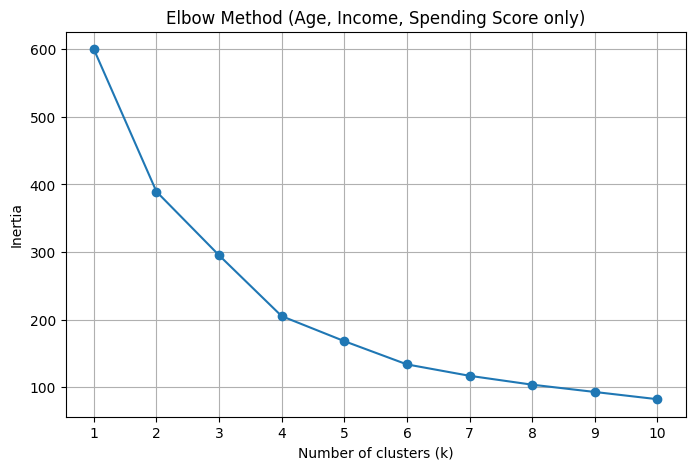

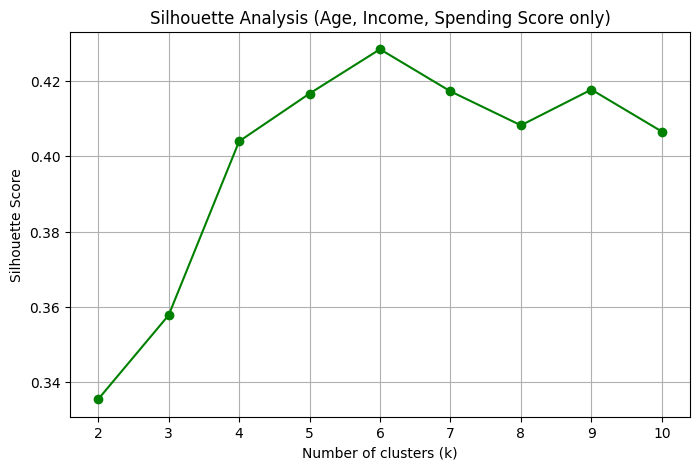


Silhouette scores by k:
k=2: silhouette score = 0.3355
k=3: silhouette score = 0.3578
k=4: silhouette score = 0.4040
k=5: silhouette score = 0.4166
k=6: silhouette score = 0.4284
k=7: silhouette score = 0.4172
k=8: silhouette score = 0.4082
k=9: silhouette score = 0.4177
k=10: silhouette score = 0.4066

Fitted K-Means with k=6
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

Cluster profiles (average values per cluster):
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        56.3                54.3                    49.1
1        26.8                57.1                    48.1
2        41.9                88.9                    17.0
3        32.7                86.5                    82.1
4        25.0                25.3                    77.6
5        45.5                26.3                    19.4

Gender distribution per cluster:
Cluster  Gender
0        Female    0.58
  

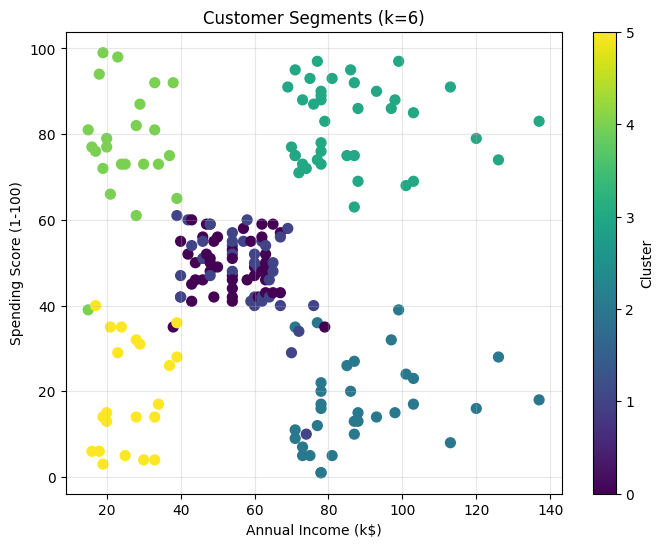

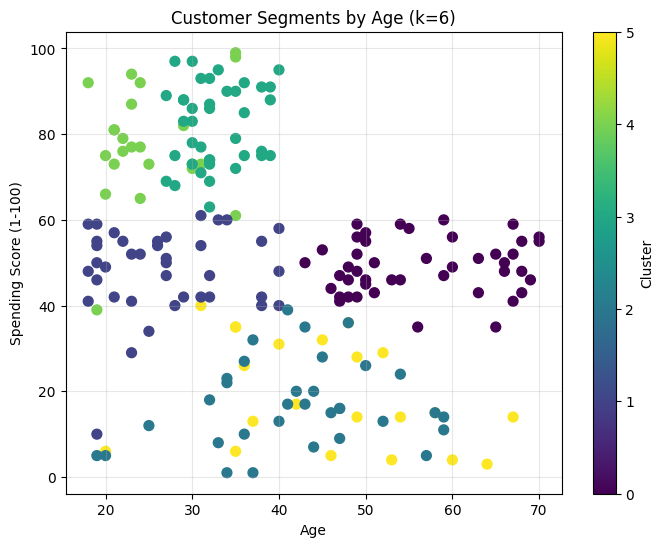

['model.pkl']

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# STEP 1: Load and explore the data
# ============================================================
df = pd.read_csv('Mall_Customers.csv')

print("First 5 rows:")
print(df.head())
print("\nData info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())

# ============================================================
# STEP 2: Clean up the data
# ============================================================
# CustomerID is just a unique identifier with no meaning for grouping — drop it
df = df.drop(columns=['CustomerID'])

# Note: we keep the Gender column in df for later profiling/reporting,
# but we will NOT include it in the features used for clustering itself.

# ============================================================
# STEP 3: Select features and scale them
# ============================================================
# Only continuous features go into the clustering — Age, Income, Spending Score.
# Gender is excluded here (see note above).
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Scaling is critical for clustering: K-Means groups points by distance,
# and features with larger raw ranges (like Income, ~15-140) would dominate
# over smaller-range features (like Spending Score, ~1-100) if left unscaled.
# StandardScaler puts every feature on the same footing (mean=0, std=1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4: Find the right number of clusters (k)
# ============================================================

# --- Elbow Method ---
# Inertia = sum of squared distances from each point to its assigned cluster center.
# It always decreases as k increases, but we're looking for the point where
# the improvement slows down sharply — the "elbow" — as a candidate for k.
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Age, Income, Spending Score only)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# --- Silhouette Score ---
# Measures how similar each point is to its own cluster vs. other clusters.
# Ranges from -1 (bad, likely wrong cluster) to +1 (well-separated, tight cluster).
# Needs at least 2 clusters, so we start from k=2.
sil_scores = []
sil_k_range = range(2, 11)

for k in sil_k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(sil_k_range, sil_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis (Age, Income, Spending Score only)')
plt.xticks(sil_k_range)
plt.grid(True)
plt.show()

print("\nSilhouette scores by k:")
for k, score in zip(sil_k_range, sil_scores):
    print(f"k={k}: silhouette score = {score:.4f}")

# ============================================================
# STEP 5: Fit the final K-Means model
# ============================================================
# k=6 chosen based on: silhouette score peaks here (~0.428), and the
# elbow curve's rate of decline clearly slows down around this point too.
k_final = 6

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nFitted K-Means with k={k_final}")
print(df['Cluster'].value_counts().sort_index())

# ============================================================
# STEP 6: Interpret the clusters
# ============================================================
# This is the actual point of clustering — turning cluster IDs (meaningless
# numbers) into a human-readable story about each customer segment.
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print("\nCluster profiles (average values per cluster):")
print(cluster_profile)

# Gender wasn't used for clustering, but we can still check its distribution
# per cluster out of curiosity — this is just descriptive, not part of the model.
gender_profile = df.groupby('Cluster')['Gender'].value_counts(normalize=True).round(2)
print("\nGender distribution per cluster:")
print(gender_profile)

# ============================================================
# STEP 7: Visualize the clusters
# ============================================================
# Income vs. Spending Score — the classic view for this dataset.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments (k={k_final})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# Bonus: Age vs. Spending Score view, since Income vs. Spending doesn't
# capture the Age dimension of the segmentation
plt.figure(figsize=(8, 6))
scatter2 = plt.scatter(
    df['Age'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments by Age (k={k_final})')
plt.colorbar(scatter2, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

import joblib

# Save everything the app needs to predict + label clusters
artifact = {
    "scaler": scaler,
    "kmeans": kmeans,
    "features": ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    "cluster_profile": cluster_profile  # the groupby(...).mean() dataframe you already built
}
joblib.dump(artifact, "model.pkl")